In [1]:
pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.8 MB/s eta 0:00:00


In [2]:
import os
import random
import re
import numpy as np
import pandas as pd
import contractions
import matplotlib.pyplot as plt
from tabulate import tabulate

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
# File paths
TRAIN_PATH = "/content/drive/MyDrive/ecommerce/train-product-review.parquet"
TEST_PATH  = "/content/drive/MyDrive/ecommerce/test-product-review.parquet"
TRANSLATED_PATH = "/content/drive/MyDrive/translated_output.csv"
TEST_TRANSLATED_PATH = "/content/drive/MyDrive/test_translated_reviews.csv"

In [6]:
# Load datasets
train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)

In [7]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (20000, 8)
Test shape: (1500, 8)


In [8]:
#checks on the dataset

print(train_df.info())
print("Language counts:\n", train_df['language'].value_counts(dropna=False))
print("Star counts:\n", train_df['stars'].value_counts().sort_index())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_id         20000 non-null  object
 1   product_id        20000 non-null  object
 2   reviewer_id       20000 non-null  object
 3   stars             20000 non-null  int32 
 4   review_body       20000 non-null  object
 5   review_title      20000 non-null  object
 6   language          20000 non-null  object
 7   product_category  20000 non-null  object
dtypes: int32(1), object(7)
memory usage: 1.1+ MB
None
Language counts:
 language
en    6736
de    6634
fr    6630
Name: count, dtype: int64
Star counts:
 stars
1    4059
2    3960
3    4006
4    3968
5    4007
Name: count, dtype: int64


In [9]:
# Context-aware duplicate removal
def remove_duplicates(df: pd.DataFrame, text_col='review_body') -> pd.DataFrame:

    df = df.copy()
    df[text_col] = df[text_col].astype(str)  # avoid NaN issues
    grouped = df.groupby(text_col, sort=False)
    keep = []

    for text, g in grouped:
        if len(g) == 1:
            keep.append(g.iloc[[0]])
            continue
        stars = g['stars'].tolist()
        mx, mn = max(stars), min(stars)
        diff = mx - mn
        if diff == 0:
            keep.append(g.iloc[[0]])
        elif diff == 1:
            row = g[g['stars'] == mx].iloc[[0]]
            keep.append(row)
        else:
            continue

    if keep:
        clean = pd.concat(keep, ignore_index=True)
    else:
        clean = pd.DataFrame(columns=df.columns)
    return clean

In [10]:
print("Deduplicating train_df (pre-translation check)...")
train_df = remove_duplicates(train_df, text_col='review_body').reset_index(drop=True)
print("After dedupe train shape:", train_df.shape)

Deduplicating train_df (pre-translation check)...
After dedupe train shape: (19983, 8)


In [11]:
!pip install deep_translator
from deep_translator import GoogleTranslator, DeeplTranslator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.5 MB/s eta 0:00:00


In [12]:
# from deep_translator import GoogleTranslator
# from tqdm import tqdm
# import pandas as pd
# from pathlib import Path   # ← Added for safe saving

# Example: small sample dataset
# train_df = pd.read_parquet("train-product-review.parquet")

# Parameters
# batch_size = 500

# Columns to store results
# train_df['translated_review'] = ""
# train_df['back_translated'] = ""
# train_df['back_translated_to_en'] = ""

# Function to translate a single review
# def translate_to_en(row):
#     if row['language'] == 'en':
#         return row['review_body']
#     try:
#         return GoogleTranslator(source='auto', target='en').translate(row['review_body'])
#     except Exception as e:
#         return f"Error: {str(e)}"

# Function to back-translate English to original language
# def back_translate(row):
#     if row['language'] == 'en':
#         return row['translated_review']
#     try:
#         return GoogleTranslator(source='en', target=row['language']).translate(row['translated_review'])
#     except Exception as e:
#         return f"Error: {str(e)}"

# Function to translate back-translated text to English
# def back_to_en(row):
#     if row['language'] == 'en':
#         return row['translated_review']
#     try:
#         return GoogleTranslator(source=row['language'], target='en').translate(row['back_translated'])
#     except Exception as e:
#         return f"Error: {str(e)}"

# Batch processing
# for start in tqdm(range(0, len(train_df), batch_size)):
#     batch = train_df.iloc[start:start+batch_size]

#     # Translate to English
#     train_df.loc[batch.index, 'translated_review'] = batch.apply(translate_to_en, axis=1)

#     # Back-translate to original language
#     train_df.loc[batch.index, 'back_translated'] = train_df.loc[batch.index].apply(back_translate, axis=1)

#     # Translate back to English
#     train_df.loc[batch.index, 'back_translated_to_en'] = train_df.loc[batch.index].apply(back_to_en, axis=1)

# print("Translation pipeline complete!")


# output_path = Path("translated_reviews.csv")

# if not output_path.exists():
#     train_df.to_csv(output_path, index=False)
#     train_df.to_csv("/content/drive/MyDrive/translated_output.csv", index=False)
#     print("File saved as translated_reviews.csv")
# else:
#     print("File already exists. Not saving.")


In [13]:
# # actual test data translation

# from deep_translator import GoogleTranslator
# from tqdm import tqdm
# import pandas as pd
# from pathlib import Path

# batch_size = 500

# test_df['translated_review'] = ""

# # Function to translate a single review to English
# def translate_to_en(row):
#     if row['language'] == 'en':
#         return row['review_body']  # Keep English reviews as-is
#     try:
#         return GoogleTranslator(source='auto', target='en').translate(row['review_body'])
#     except Exception as e:
#         return f"Error: {str(e)}"

#         # Batch processing
# for start in tqdm(range(0, len(test_df), batch_size)):
#     batch = test_df.iloc[start:start + batch_size]
#     test_df.loc[batch.index, 'translated_review'] = batch.apply(
#         translate_to_en, axis=1)

# print("Test translation pipeline complete!")

# # Save to CSV
# output_path = Path("test_translated_reviews.csv")
# if not output_path.exists():
#     test_df.to_csv(output_path, index=False)
#     print(f"File saved as {output_path}")
# else:
#     print("File already exists. Not saving.")

In [14]:
#loading the training dataset

if os.path.exists(TRANSLATED_PATH):
    translate_df = pd.read_csv(TRANSLATED_PATH)
    # ensure expected columns exist
    if 'translated_review' not in translate_df.columns:
        raise RuntimeError("translated_output.csv exists but has no 'translated_review' column.")
    translate_df = translate_df[['translated_review','stars','language']] if 'language' in translate_df.columns else translate_df[['translated_review','stars']]
    translate_df['translated_review'] = translate_df['translated_review'].astype(str)
    print("Loaded translated data:", translate_df.shape)
else:
    # No pre-translated file — create translated_review using review_body for English records
    # (You can replace this with a proper translation pipeline if you choose)
    translate_df = train_df.copy()
    translate_df['translated_review'] = translate_df['review_body'].astype(str)
    print("No translated file found — using original review_body as translated_review for English-only subset.")
    print("translate_df shape:", translate_df.shape)

Loaded translated data: (19983, 3)


In [15]:
#loading the testing dataset

TEST_TRANSLATED_PATH = "/content/drive/MyDrive/test_translated_reviews.csv"

if os.path.exists(TEST_TRANSLATED_PATH):
    test_translate_df = pd.read_csv(TEST_TRANSLATED_PATH)

    # Ensure required column exists
    if 'translated_review' not in test_translate_df.columns:
        raise RuntimeError(
            "test_translated_output.csv exists but has no 'translated_review' column."
        )

    # Keep only relevant columns
    if 'language' in test_translate_df.columns:
        test_translate_df = test_translate_df[['translated_review', 'stars', 'language']]
    else:
        test_translate_df = test_translate_df[['translated_review', 'stars']]

    # Ensure text column is string
    test_translate_df['translated_review'] = test_translate_df['translated_review'].astype(str)

    print("Loaded translated TEST data:", test_translate_df.shape)

else:
    # Fallback: use original test reviews (English-only assumption)
    test_translate_df = test_df.copy()
    test_translate_df['translated_review'] = test_translate_df['review_body'].astype(str)

    print(
        "No translated test file found — using original review_body "
        "as translated_review for test set."
    )
    print("test_translate_df shape:", test_translate_df.shape)


Loaded translated TEST data: (1500, 3)


In [16]:
translate_df = remove_duplicates(translate_df, text_col='translated_review').reset_index(drop=True)
print("After dedupe (post-translation) translate_df shape:", translate_df.shape)

After dedupe (post-translation) translate_df shape: (19967, 3)


In [17]:
# Convert star ratings to sentiment labels
def sentiment_rate(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"
# loading the translated review and apply the sentiment rate function
translate_df['sentiment'] = translate_df['stars'].apply(sentiment_rate)
print("Sentiment distribution:\n", translate_df['sentiment'].value_counts())


Sentiment distribution:
 sentiment
Negative    8012
Positive    7952
Neutral     4003
Name: count, dtype: int64


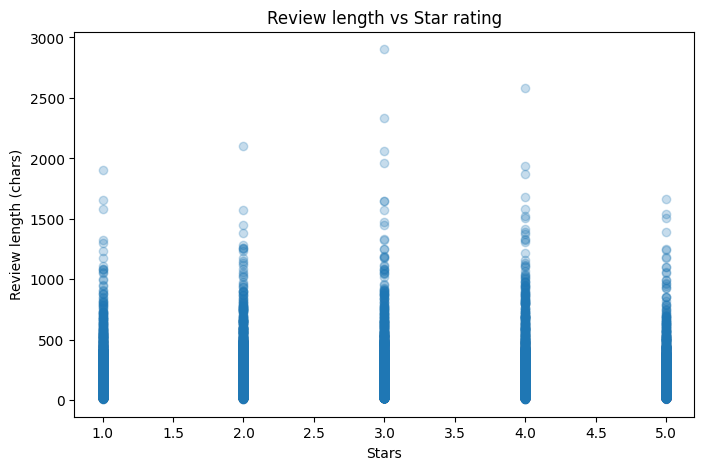

In [18]:
# Review length vs rating
translate_df['review_length'] = translate_df['translated_review'].astype(str).map(len)
plt.figure(figsize=(8,5))
plt.scatter(translate_df['stars'], translate_df['review_length'], alpha=0.25)
plt.xlabel("Stars"); plt.ylabel("Review length (chars)")
plt.title("Review length vs Star rating")
plt.show()

In [19]:
# Keyword-based label consistency check (helps find candidate mislabels)
negative_words = ['bad','poor','waste','disappointed','broken','terrible','awful']
positive_words = ['love','great','excellent','amazing','recommend','best']

# lower once and cache
translate_df['_lower_text'] = translate_df['translated_review'].astype(str).str.lower()

translate_df['has_negative_word'] = translate_df['_lower_text'].apply(lambda x: any(w in x for w in negative_words))
translate_df['has_positive_word'] = translate_df['_lower_text'].apply(lambda x: any(w in x for w in positive_words))

potential_wrong = translate_df[
    ((translate_df['sentiment'] == 'Positive') & translate_df['has_negative_word']) |
    ((translate_df['sentiment'] == 'Negative') & translate_df['has_positive_word'])
].copy()

print(f"Potential flagged samples: {len(potential_wrong)} ({len(potential_wrong)/len(translate_df):.2%})")
if len(potential_wrong) > 0:
    print(tabulate(potential_wrong[['translated_review','stars','sentiment']].head(20), headers='keys', tablefmt='github'))



Potential flagged samples: 1327 (6.65%)
|     | translated_review                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [20]:
# drop helper column
translate_df.drop(columns=['_lower_text'], inplace=True)

In [21]:
from sklearn.model_selection import train_test_split

X_series = translate_df['translated_review'].astype(str)
y_series = translate_df['sentiment']

X_train_ser, X_valid_ser, y_train_ser, y_valid_ser = train_test_split(
    X_series, y_series, test_size=0.20, random_state=SEED, stratify=y_series
)

In [22]:
# Convert to reset indexed Series for convenience
X_train_ser = X_train_ser.reset_index(drop=True)
X_valid_ser = X_valid_ser.reset_index(drop=True)
y_train_ser = y_train_ser.reset_index(drop=True)
y_valid_ser = y_valid_ser.reset_index(drop=True)

print("Train / Valid sizes:", X_train_ser.shape, X_valid_ser.shape)

Train / Valid sizes: (15973,) (3994,)


In [23]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer

stopwords_en = set(stopwords.words('english'))
# keep canonical negation tokens only (contractions expanded first)
negations_en = set(['not', 'no', 'never', 'cannot'])


In [24]:
lemmatizer = WordNetLemmatizer()
stemmer = SnowballStemmer('english')

In [25]:
def preprocess_classical(series: pd.Series):

    out = []
    for raw in series:
        raw = "" if pd.isna(raw) else str(raw)
        text = contractions.fix(raw)               # expand contractions first ("don't" -> "do not")
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)   # keep letters & whitespace
        tokens = text.lower().split()
        tokens = [t for t in tokens if (t in negations_en) or (t not in stopwords_en)]
        tokens = [t for t in tokens if len(t) > 1]
        tokens = [stemmer.stem(t) for t in tokens]
        # tokens = [lemmatizer.lemmatize(t) for t in tokens]
        cleaned = " ".join(tokens).strip()
        out.append(cleaned if cleaned else "empty")
    return out

def preprocess_for_nn(series: pd.Series):
    out = []
    for raw in series:
        raw = "" if pd.isna(raw) else str(raw)
        text = contractions.fix(raw)
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        text = text.lower().strip()
        out.append(text if text else "empty")
    return out

In [26]:
train_corpus = preprocess_classical(X_train_ser)
valid_corpus = preprocess_classical(X_valid_ser)
train_corpus_nn = preprocess_for_nn(X_train_ser)
valid_corpus_nn = preprocess_for_nn(X_valid_ser)

In [27]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

BOW_MAX_FEAT = 2000
TFIDF_MAX_FEAT = 2000

bow_vectorizer = CountVectorizer(max_features=BOW_MAX_FEAT, ngram_range=(1,2), min_df=2)
tfidf_vectorizer = TfidfVectorizer(max_features=TFIDF_MAX_FEAT, ngram_range=(1,2), min_df=2)

In [28]:
X_train_bow = bow_vectorizer.fit_transform(train_corpus)     # sparse
X_valid_bow = bow_vectorizer.transform(valid_corpus)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_corpus) # sparse
X_valid_tfidf = tfidf_vectorizer.transform(valid_corpus)

print("BOW shape:", X_train_bow.shape, "TFIDF shape:", X_train_tfidf.shape)


BOW shape: (15973, 2000) TFIDF shape: (15973, 2000)


In [29]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_ser)
y_valid_enc = le.transform(y_valid_ser)
print("Classes:", le.classes_)

Classes: ['Negative' 'Neutral' 'Positive']


In [30]:
# Classical models: Logistic Regression (TF-IDF), Naive Bayes, LinearSVC

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [31]:
# Logistic Regression on TF-IDF
log_tfidf = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)
log_tfidf.fit(X_train_tfidf, y_train_ser)
y_pred_log = log_tfidf.predict(X_valid_tfidf)


In [32]:
# Naive Bayes on TF-IDF
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train_ser)
y_pred_nb = nb_tfidf.predict(X_valid_tfidf)


In [33]:
# Linear SVM on TF-IDF
svm_tfidf = LinearSVC(class_weight='balanced', random_state=SEED, max_iter=5000)
svm_tfidf.fit(X_train_tfidf, y_train_ser)
y_pred_svm = svm_tfidf.predict(X_valid_tfidf)


In [34]:
#Evaluation of the train and validation
print("Evaluation of the train and validation (TF-IDF)\n")
print("Logistic(TFIDF) Accuracy:", accuracy_score(y_valid_ser, y_pred_log))
print(classification_report(y_valid_ser, y_pred_log))

print("NB(TFIDF) Accuracy:", accuracy_score(y_valid_ser, y_pred_nb))
print(classification_report(y_valid_ser, y_pred_nb))

print("SVM(TFIDF) Accuracy:", accuracy_score(y_valid_ser, y_pred_svm))
print(classification_report(y_valid_ser, y_pred_svm))


Evaluation of the train and validation (TF-IDF)

Logistic(TFIDF) Accuracy: 0.6832749123685529
              precision    recall  f1-score   support

    Negative       0.76      0.70      0.73      1603
     Neutral       0.38      0.47      0.42       801
    Positive       0.80      0.77      0.79      1590

    accuracy                           0.68      3994
   macro avg       0.65      0.65      0.65      3994
weighted avg       0.70      0.68      0.69      3994

NB(TFIDF) Accuracy: 0.6905358037055583
              precision    recall  f1-score   support

    Negative       0.69      0.84      0.76      1603
     Neutral       0.51      0.07      0.13       801
    Positive       0.71      0.85      0.77      1590

    accuracy                           0.69      3994
   macro avg       0.63      0.59      0.55      3994
weighted avg       0.66      0.69      0.64      3994

SVM(TFIDF) Accuracy: 0.6952929394091136
              precision    recall  f1-score   support

    Negati

In [35]:
# Classical models: Logistic Regression (Bag of Word), Naive Bayes, LinearSVC

# Logistic Regression on Bow
log_bow = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)
log_bow.fit(X_train_bow, y_train_ser)
y_pred_log = log_bow.predict(X_valid_bow)


In [36]:
# Naive Bayes on Bow
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train_ser)
y_pred_nb_Bow = nb_bow.predict(X_valid_bow)


In [37]:
# Linear SVM on Bow
svm_Bow = LinearSVC(class_weight='balanced', random_state=SEED, max_iter=5000)
svm_Bow.fit(X_train_bow, y_train_ser)
y_pred_svm_Bow = svm_Bow.predict(X_valid_bow)


In [38]:
#Evaluation of training and validation (BOw)
print("Evaluation of the train and validation (BOW)\n")
print("Logistic(Bow) Accuracy:", accuracy_score(y_valid_ser, y_pred_log))
print(classification_report(y_valid_ser, y_pred_log))

print("NB(Bow) Accuracy:", accuracy_score(y_valid_ser, y_pred_nb_Bow))
print(classification_report(y_valid_ser, y_pred_nb_Bow))

print("SVM(Bow) Accuracy:", accuracy_score(y_valid_ser, y_pred_svm_Bow))
print(classification_report(y_valid_ser, y_pred_svm_Bow))

Evaluation of the train and validation (BOW)

Logistic(Bow) Accuracy: 0.6632448673009514
              precision    recall  f1-score   support

    Negative       0.75      0.69      0.72      1603
     Neutral       0.36      0.42      0.39       801
    Positive       0.77      0.76      0.77      1590

    accuracy                           0.66      3994
   macro avg       0.63      0.62      0.62      3994
weighted avg       0.68      0.66      0.67      3994

NB(Bow) Accuracy: 0.6862794191286931
              precision    recall  f1-score   support

    Negative       0.73      0.74      0.73      1603
     Neutral       0.39      0.33      0.36       801
    Positive       0.76      0.81      0.79      1590

    accuracy                           0.69      3994
   macro avg       0.63      0.63      0.63      3994
weighted avg       0.68      0.69      0.68      3994

SVM(Bow) Accuracy: 0.6780170255383074
              precision    recall  f1-score   support

    Negative       

In [39]:
# LSTM model (neural) — use tokenizer on preprocessed NN corpus
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense, Bidirectional


In [40]:
tf.random.set_seed(SEED)
MAX_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_corpus_nn)

In [41]:
# Calculate actual vocab size (safe for Embedding input_dim)
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print("Vocab size for embedding:", vocab_size)

Vocab size for embedding: 14913


In [42]:
X_train_seq = tokenizer.texts_to_sequences(train_corpus_nn)
X_valid_seq = tokenizer.texts_to_sequences(valid_corpus_nn)

In [43]:
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_valid_pad = pad_sequences(X_valid_seq, maxlen=MAX_LEN, padding='post', truncating='post')

In [44]:
# categorical labels for NN
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train_enc)
y_valid_cat = to_categorical(y_valid_enc)

In [45]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

history = model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_valid_pad, y_valid_cat),
    epochs=5,
    batch_size=64,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.5354 - loss: 0.9468 - val_accuracy: 0.6950 - val_loss: 0.7101
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7142 - loss: 0.6656 - val_accuracy: 0.7001 - val_loss: 0.7199
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7764 - loss: 0.5334 - val_accuracy: 0.6718 - val_loss: 0.7961
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8242 - loss: 0.4476 - val_accuracy: 0.6685 - val_loss: 1.1097
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8345 - loss: 0.4211 - val_accuracy: 0.6657 - val_loss: 1.0515


In [46]:
loss, acc = model.evaluate(X_valid_pad, y_valid_cat, verbose=0)
print("BiLSTM-RNN validation accuracy:", acc)

BiLSTM-RNN validation accuracy: 0.6657485961914062


In [47]:
# Predict and convert back to original labels
y_pred_probs = model.predict(X_valid_pad)
y_pred_int = np.argmax(y_pred_probs, axis=1)
y_pred_labels = le.inverse_transform(y_pred_int)


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [48]:
print("BiLSTM-RNN  Validation Classification report:")
print(classification_report(y_valid_ser, y_pred_labels))

BiLSTM-RNN  Validation Classification report:
              precision    recall  f1-score   support

    Negative       0.68      0.80      0.73      1603
     Neutral       0.35      0.29      0.32       801
    Positive       0.80      0.72      0.76      1590

    accuracy                           0.67      3994
   macro avg       0.61      0.60      0.60      3994
weighted avg       0.66      0.67      0.66      3994



In [49]:
!pip install tensorflow

from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D


In [50]:
model_cnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=MAX_LEN),

    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),

    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(len(le.classes_), activation='softmax')
])

model_cnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_cnn.summary()

history_cnn = model_cnn.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_valid_pad, y_valid_cat),
    epochs=5,
    batch_size=32,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.5447 - loss: 0.9388 - val_accuracy: 0.7063 - val_loss: 0.6956
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7131 - loss: 0.6699 - val_accuracy: 0.7056 - val_loss: 0.7057
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7905 - loss: 0.5061 - val_accuracy: 0.6950 - val_loss: 0.8361
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8684 - loss: 0.3388 - val_accuracy: 0.6855 - val_loss: 1.0222
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9230 - loss: 0.2107 - val_accuracy: 0.6680 - val_loss: 1.4426


In [51]:
loss_cnn, acc_cnn = model_cnn.evaluate(X_valid_pad, y_valid_cat, verbose=0)
print("CNN validation accuracy:", acc_cnn)


CNN validation accuracy: 0.6680020093917847


In [52]:
# Predict and convert back to original labels
y_pred_probs_cnn = model_cnn.predict(X_valid_pad)
y_pred_int_cnn = np.argmax(y_pred_probs_cnn, axis=1)
y_pred_labels_cnn = le.inverse_transform(y_pred_int_cnn)

print("Text-CNN Classification report:")
print(classification_report(y_valid_ser, y_pred_labels_cnn))


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Text-CNN Classification report:
              precision    recall  f1-score   support

    Negative       0.64      0.86      0.74      1603
     Neutral       0.38      0.23      0.29       801
    Positive       0.81      0.69      0.75      1590

    accuracy                           0.67      3994
   macro avg       0.61      0.59      0.59      3994
weighted avg       0.66      0.67      0.65      3994



In [53]:
#Testing and Evaluation of the models

In [54]:
test_translate_df = test_translate_df[['translated_review', 'stars']]


In [55]:

test_translate_df['sentiment'] = test_translate_df['stars'].apply(sentiment_rate)

In [56]:
X_test_ser = test_translate_df['translated_review'].astype(str)
y_test_ser = test_translate_df['sentiment']

In [57]:
test_corpus = preprocess_classical(X_test_ser)
test_corpus_nn = preprocess_for_nn(X_test_ser)


In [58]:
X_test_bow = bow_vectorizer.transform(test_corpus)
X_test_tfidf = tfidf_vectorizer.transform(test_corpus)

In [59]:
#Logistic Regression (TF-IDF)
test_pred_log_tfidf = log_tfidf.predict(X_test_tfidf)
#Naive Bayes (TF-IDF)
test_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
#SVM (TF-IDF)
test_pred_svm = svm_tfidf.predict(X_test_tfidf)



In [60]:
#Logistic Regression (Bow)
test_pred_log_Bow = log_bow.predict(X_test_bow)
#Naive Bayes (Bow))
test_pred_nb_Bow = nb_bow.predict(X_test_bow)
#SVM (Bow)
test_pred_svm_Bow = svm_Bow.predict(X_test_bow)


In [61]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic (TF-IDF) TEST Accuracy:",
      accuracy_score(y_test_ser, test_pred_log_tfidf))
print(classification_report(y_test_ser, test_pred_log_tfidf))

print("NB (TF-IDF) TEST Accuracy:",
      accuracy_score(y_test_ser, test_pred_nb_tfidf))
print(classification_report(y_test_ser, test_pred_nb_tfidf))

print("SVM (TF-IDF) TEST Accuracy:",
      accuracy_score(y_test_ser, test_pred_svm))
print(classification_report(y_test_ser, test_pred_svm))


Logistic (TF-IDF) TEST Accuracy: 0.6626666666666666
              precision    recall  f1-score   support

    Negative       0.78      0.68      0.73       596
     Neutral       0.34      0.48      0.40       292
    Positive       0.79      0.73      0.76       612

    accuracy                           0.66      1500
   macro avg       0.64      0.63      0.63      1500
weighted avg       0.70      0.66      0.68      1500

NB (TF-IDF) TEST Accuracy: 0.6873333333333334
              precision    recall  f1-score   support

    Negative       0.70      0.83      0.76       596
     Neutral       0.38      0.07      0.12       292
    Positive       0.70      0.84      0.77       612

    accuracy                           0.69      1500
   macro avg       0.59      0.58      0.55      1500
weighted avg       0.64      0.69      0.64      1500

SVM (TF-IDF) TEST Accuracy: 0.6573333333333333
              precision    recall  f1-score   support

    Negative       0.73      0.71     

In [62]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic (Bow) TEST Accuracy:",
      accuracy_score(y_test_ser, test_pred_log_Bow))
print(classification_report(y_test_ser, test_pred_log_Bow))

print("NB (BOW) TEST Accuracy:",
      accuracy_score(y_test_ser, test_pred_nb_Bow))
print(classification_report(y_test_ser, test_pred_nb_Bow))

print("SVM (TF-IDF) TEST Accuracy:",
      accuracy_score(y_test_ser, test_pred_svm_Bow))
print(classification_report(y_test_ser, test_pred_svm_Bow))

Logistic (Bow) TEST Accuracy: 0.642
              precision    recall  f1-score   support

    Negative       0.75      0.65      0.70       596
     Neutral       0.33      0.43      0.37       292
    Positive       0.76      0.73      0.74       612

    accuracy                           0.64      1500
   macro avg       0.61      0.60      0.60      1500
weighted avg       0.67      0.64      0.65      1500

NB (BOW) TEST Accuracy: 0.6713333333333333
              precision    recall  f1-score   support

    Negative       0.75      0.72      0.73       596
     Neutral       0.35      0.33      0.34       292
    Positive       0.74      0.79      0.77       612

    accuracy                           0.67      1500
   macro avg       0.61      0.61      0.61      1500
weighted avg       0.67      0.67      0.67      1500

SVM (TF-IDF) TEST Accuracy: 0.6533333333333333
              precision    recall  f1-score   support

    Negative       0.73      0.70      0.72       596
   

In [63]:
#Prepare test data for neural models

X_test_seq = tokenizer.texts_to_sequences(test_corpus_nn)
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)


In [64]:
#Encode labels

y_test_enc = le.transform(y_test_ser)
y_test_cat = to_categorical(y_test_enc)


In [65]:
#Evaluate BiLSTM model on test set

loss_test, acc_test = model.evaluate(X_test_pad, y_test_cat, verbose=0)
print("BiLSTM TEST Accuracy:", acc_test)

y_test_probs = model.predict(X_test_pad)
y_test_pred = le.inverse_transform(np.argmax(y_test_probs, axis=1))

print(classification_report(y_test_ser, y_test_pred))


BiLSTM TEST Accuracy: 0.6666666865348816
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

    Negative       0.70      0.80      0.75       596
     Neutral       0.34      0.31      0.32       292
    Positive       0.79      0.70      0.74       612

    accuracy                           0.67      1500
   macro avg       0.61      0.61      0.61      1500
weighted avg       0.67      0.67      0.66      1500



In [66]:
#Evaluate CNN model on test set
loss_test_cnn, acc_test_cnn = model_cnn.evaluate(X_test_pad, y_test_cat, verbose=0)
print("CNN TEST Accuracy:", acc_test_cnn)

y_test_probs_cnn = model_cnn.predict(X_test_pad)
y_test_pred_cnn = le.inverse_transform(np.argmax(y_test_probs_cnn, axis=1))

print(classification_report(y_test_ser, y_test_pred_cnn))


CNN TEST Accuracy: 0.6586666703224182
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

    Negative       0.65      0.86      0.74       596
     Neutral       0.34      0.22      0.27       292
    Positive       0.79      0.67      0.73       612

    accuracy                           0.66      1500
   macro avg       0.59      0.58      0.58      1500
weighted avg       0.65      0.66      0.64      1500

